In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set(font_scale=1.1)


df = pd.read_csv(r"C:\Users\NTC\Desktop\project\dataset.csv")

df.head()


,timestamp,hour,dayofweek,is_weekend,hour_sin,hour_cos,month_sin,month_cos,temp_C,wind_speed_m_s,...,hybrid_gen_kWh,net_balance_kWh,grid_import_est_kWh,grid_export_est_kWh,energy_cost_JOD_est,export_revenue_JOD_est,net_cost_JOD_est,renewable_fraction,is_peak_18_22,day_of_year
0,2023-12-31 21:00:00,21,6,1,-0.707107,0.707107,-0.5,0.866025,10.58,2.56,...,0.000,1.700,1.700,0.0,0.285600,0.0,0.285600,0.000000,1,365
1,2023-12-31 22:00:00,22,6,1,-0.500000,0.866025,-0.5,0.866025,10.05,2.68,...,0.000,1.704,1.704,0.0,0.286272,0.0,0.286272,0.000000,1,365
2,2023-12-31 23:00:00,23,6,1,-0.258819,0.965926,-0.5,0.866025,9.59,2.73,...,0.000,1.582,1.582,0.0,0.211988,0.0,0.211988,0.000000,0,365
3,2024-01-01 00:00:00,0,0,0,0.000000,1.000000,0.0,1.000000,9.17,2.79,...,0.000,0.874,0.874,0.0,0.117116,0.0,0.117116,0.000000,0,1
4,2024-01-01 01:00:00,1,0,0,0.258819,0.965926,0.0,1.000000,8.78,2.92,...,0.072,0.695,0.695,0.0,0.093130,0.0,0.093130,0.093872,0,1


In [5]:
df.columns


Index(['timestamp', 'hour', 'dayofweek', 'is_weekend', 'hour_sin', 'hour_cos',
       'month_sin', 'month_cos', 'temp_C', 'wind_speed_m_s', 'wind_dir_deg',
       'GHI_W_m2', 'pv_kWh', 'wind_kW', 'wind_kWh', 'load_kWh',
       'tariff_JOD_per_kWh', 'export_tariff_JOD_per_kWh',
       'battery_capacity_kWh', 'battery_roundtrip_efficiency', 'pv_system_kWp',
       'inverter_limit_kW', 'wind_speed_hub_m_s', 'air_density_kg_m3',
       'pv_kW_est', 'battery_charge_power_kW', 'battery_discharge_power_kW',
       'battery_degradation_cost_JOD_per_kWh_throughput',
       'grid_import_limit_kW', 'grid_export_limit_kW',
       'tariff_fils_per_kWh_raw', 'hybrid_gen_kWh', 'net_balance_kWh',
       'grid_import_est_kWh', 'grid_export_est_kWh', 'energy_cost_JOD_est',
       'export_revenue_JOD_est', 'net_cost_JOD_est', 'renewable_fraction',
       'is_peak_18_22', 'day_of_year'],
      dtype='object')

In [7]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.set_index("timestamp").sort_index()

df.index.dtype, df.head()


(dtype('<M8[ns]'),
                      hour  dayofweek  is_weekend  hour_sin  hour_cos  \
 timestamp                                                              
 2023-12-31 21:00:00    21          6           1 -0.707107  0.707107   
 2023-12-31 22:00:00    22          6           1 -0.500000  0.866025   
 2023-12-31 23:00:00    23          6           1 -0.258819  0.965926   
 2024-01-01 00:00:00     0          0           0  0.000000  1.000000   
 2024-01-01 01:00:00     1          0           0  0.258819  0.965926   
 
                      month_sin  month_cos  temp_C  wind_speed_m_s  \
 timestamp                                                           
 2023-12-31 21:00:00       -0.5   0.866025   10.58            2.56   
 2023-12-31 22:00:00       -0.5   0.866025   10.05            2.68   
 2023-12-31 23:00:00       -0.5   0.866025    9.59            2.73   
 2024-01-01 00:00:00        0.0   1.000000    9.17            2.79   
 2024-01-01 01:00:00        0.0   1.000000    8.

In [11]:

df.shape




(17547, 40)

In [13]:


df.dtypes




hour                                                 int64
dayofweek                                            int64
is_weekend                                           int64
hour_sin                                           float64
hour_cos                                           float64
month_sin                                          float64
month_cos                                          float64
temp_C                                             float64
wind_speed_m_s                                     float64
wind_dir_deg                                       float64
GHI_W_m2                                           float64
pv_kWh                                             float64
wind_kW                                            float64
wind_kWh                                           float64
load_kWh                                           float64
tariff_JOD_per_kWh                                 float64
export_tariff_JOD_per_kWh                          float

In [15]:

df.isna().sum().sort_values(ascending=False).head(20)


hour                                               0
dayofweek                                          0
air_density_kg_m3                                  0
pv_kW_est                                          0
battery_charge_power_kW                            0
battery_discharge_power_kW                         0
battery_degradation_cost_JOD_per_kWh_throughput    0
grid_import_limit_kW                               0
grid_export_limit_kW                               0
tariff_fils_per_kWh_raw                            0
hybrid_gen_kWh                                     0
net_balance_kWh                                    0
grid_import_est_kWh                                0
grid_export_est_kWh                                0
energy_cost_JOD_est                                0
export_revenue_JOD_est                             0
net_cost_JOD_est                                   0
renewable_fraction                                 0
is_peak_18_22                                 

In [17]:
energy_cols = [
    "pv_kWh", "wind_kWh", "load_kWh",
    "hybrid_gen_kWh", "net_balance_kWh",
    "grid_import_est_kWh", "grid_export_est_kWh",
]

power_cols = [
    "pv_kW_est", "wind_kW",
    "battery_charge_power_kW", "battery_discharge_power_kW",
    "inverter_limit_kW", "grid_import_limit_kW", "grid_export_limit_kW",
]


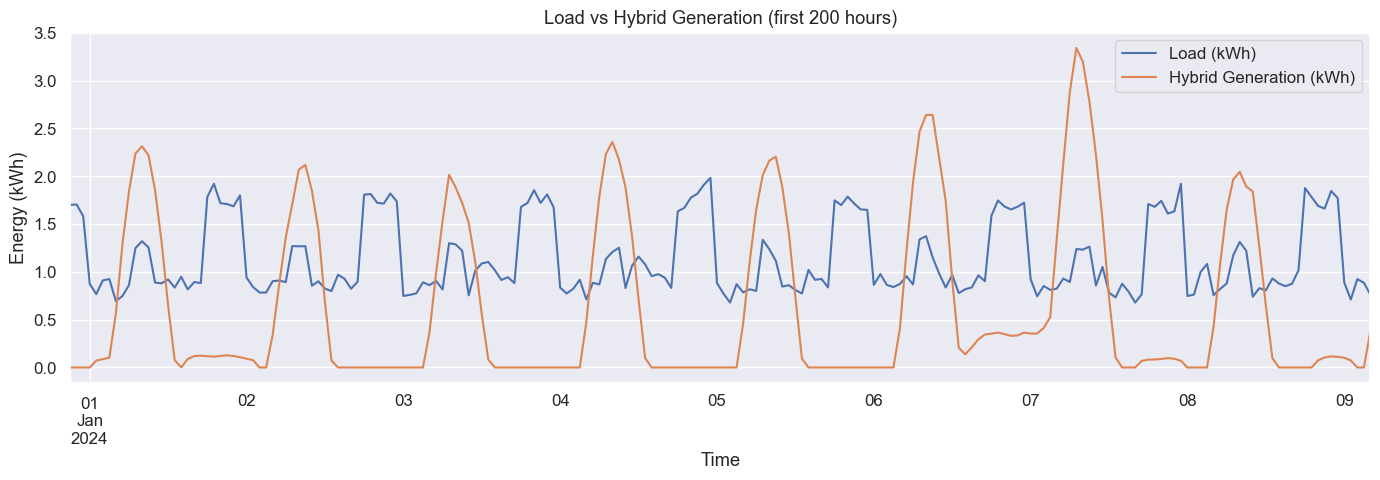

In [19]:
sample = df.iloc[:200]  

plt.figure(figsize=(14,5))
sample["load_kWh"].plot(label="Load (kWh)")
sample["hybrid_gen_kWh"].plot(label="Hybrid Generation (kWh)")
plt.legend()
plt.title("Load vs Hybrid Generation (first 200 hours)")
plt.xlabel("Time")
plt.ylabel("Energy (kWh)")
plt.tight_layout()
plt.show()


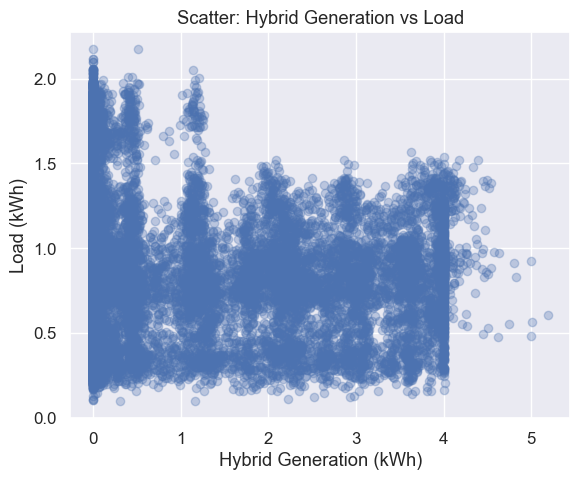

In [21]:
plt.figure(figsize=(6,5))
plt.scatter(df["hybrid_gen_kWh"], df["load_kWh"], alpha=0.3)
plt.xlabel("Hybrid Generation (kWh)")
plt.ylabel("Load (kWh)")
plt.title("Scatter: Hybrid Generation vs Load")
plt.tight_layout()
plt.show()


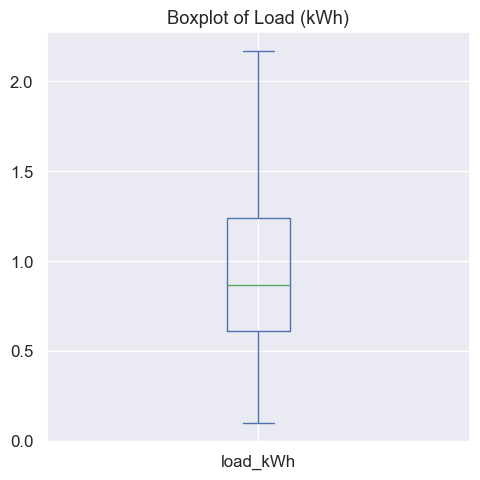

In [23]:
plt.figure(figsize=(5,5))
df["load_kWh"].plot(kind="box")
plt.title("Boxplot of Load (kWh)")
plt.tight_layout()
plt.show()


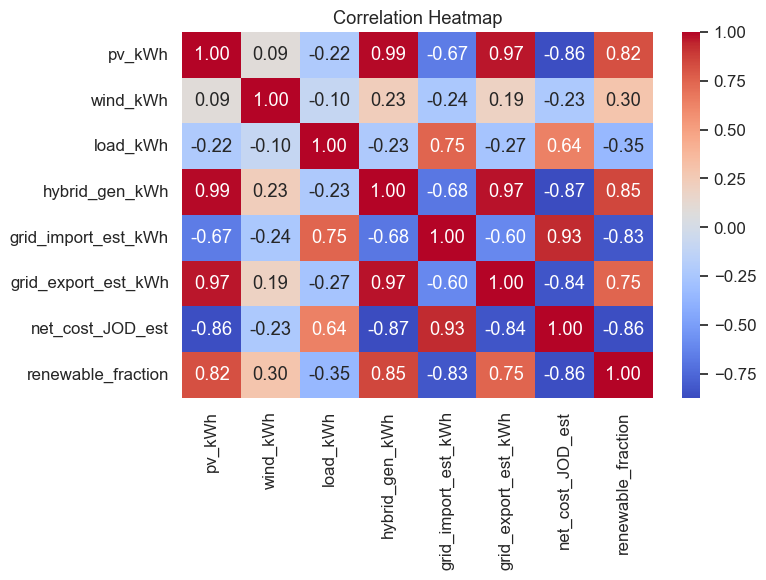

In [25]:
cols_for_corr = [
    "pv_kWh",
    "wind_kWh",
    "load_kWh",
    "hybrid_gen_kWh",
    "grid_import_est_kWh",
    "grid_export_est_kWh",
    "net_cost_JOD_est",
    "renewable_fraction",
]

corr = df[cols_for_corr].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


In [31]:
n = len(df)
split_idx = int(0.8 * n)

df_train = df.iloc[:split_idx].copy()
df_test  = df.iloc[split_idx:].copy()

df_train.shape, df_test.shape




((14037, 40), (3510, 40))

In [37]:
import zipfile

with zipfile.ZipFile("datasets.zip", 'w') as zipf:
    zipf.write("dataset_clean.csv")
    zipf.write("dataset_train.csv")
    zipf.write("dataset_test.csv")

print("ZIP created successfully")



ZIP created successfully
